In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Requirements to Explore:

1. Cleaning & preparing it
2. Age & Gender influence on purchases
3. Time-based sales patterns
4. Product category popularity
5. Age, spending & product preference relationships
6. Seasonal shopping habits
7. Quantity-per-transaction behavior
8. Price distribution within categories

In [4]:
#load the dataset

df = pd.read_csv("C:/Users/rmhar/Downloads/retail_sales_dataset.csv")
df.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,11/24/2023,CUST001,Male,34,Beauty,3,50,150
1,2,2/27/2023,CUST002,Female,26,Clothing,2,500,1000
2,3,1/13/2023,CUST003,Male,50,Electronics,1,30,30
3,4,5/21/2023,CUST004,Male,37,Clothing,1,500,500
4,5,5/6/2023,CUST005,Male,30,Beauty,2,50,100


In [5]:
#inspect the data 

df.shape
df.dtypes
df.isnull().sum()


Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [6]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [7]:
# clean and prepare the data 

df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [9]:
df['Month'] = df['Date'].dt.month_name()

df['Month_Num'] = df['Date'].dt.month

df['Weekday'] = df['Date'].dt.day_name()

bins = [18,25,35,45,55,65]
labels = ['18 - 25', '26 - 35', '36 - 45', '46 - 55', '56 - 65']
df['Age Group'] = pd.cut(df['Age'],bins = bins, labels = labels)


df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Month_Num,Weekday,Age Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,November,11,Friday,26 - 35
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,February,2,Monday,26 - 35
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,January,1,Friday,46 - 55
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,May,5,Sunday,36 - 45
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,May,5,Saturday,26 - 35


In [21]:
def get_season(Month):
    if Month in ['December','January','Febuary']: return 'Winter'
    elif Month in ['March','April','May']: return 'Spring'
    elif Month in ['June','July','August']: return 'Summer'
    else: return 'Fall'

df['Season'] = df['Month'].apply(get_season)
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Month_Num,Weekday,Age Group,Season
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,November,11,Friday,26 - 35,Fall
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,February,2,Monday,26 - 35,Fall
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,January,1,Friday,46 - 55,Winter
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,May,5,Sunday,36 - 45,Spring
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,May,5,Saturday,26 - 35,Spring


In [10]:
# age vs gender influence their purchasing behavior
Gender_summary = df.groupby('Gender').agg(
    avg_Spend = ('Total Amount' , 'mean'),
    Total_Revenue = ('Total Amount' , 'sum'),
    Transactions = ('Transaction ID', 'count')
).round(2)
print(Gender_summary)


        avg_Spend  Total_Revenue  Transactions
Gender                                        
Female     456.55         232840           510
Male       455.43         223160           490


C:\Users\rmhar\AppData\Local\Temp\ipykernel_25376\4120668867.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = df, x = 'Gender' ,y = 'Total Amount' ,estimator=np.mean, errorbar=None, ax=axes[0] ,  palette='Set2')
C:\Users\rmhar\AppData\Local\Temp\ipykernel_25376\4120668867.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Gender', ax=axes[1], palette='Set2')


<Figure size 700x400 with 0 Axes>

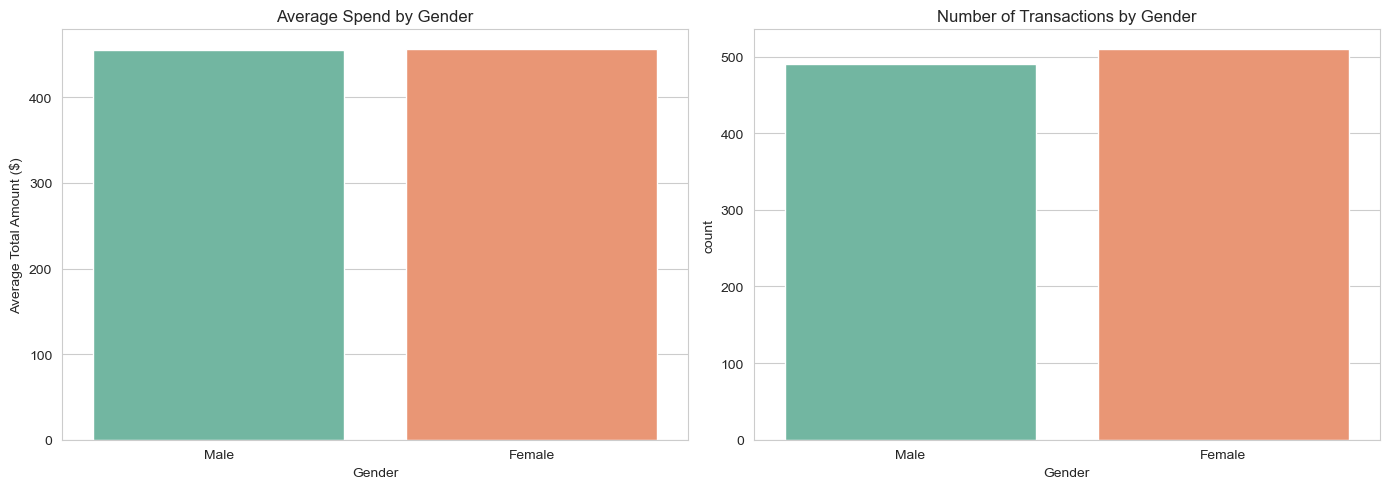

In [11]:
# Visualization: Average spend by gender

sns.set_style('whitegrid')
#plt.rcParams['figure.figsize'] = (10, 6)

plt.figure(figsize=(7,4))

fig, axes = plt.subplots(1,2 , figsize = (14,5))
sns.barplot(data = df, x = 'Gender' ,y = 'Total Amount' ,estimator=np.mean, errorbar=None, ax=axes[0] ,  palette='Set2')
axes[0].set_title('Average Spend by Gender')
axes[0].set_ylabel('Average Total Amount ($)')

sns.countplot(data=df, x='Gender', ax=axes[1], palette='Set2')
axes[1].set_title('Number of Transactions by Gender')

plt.tight_layout()
#plt.savefig('gender_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

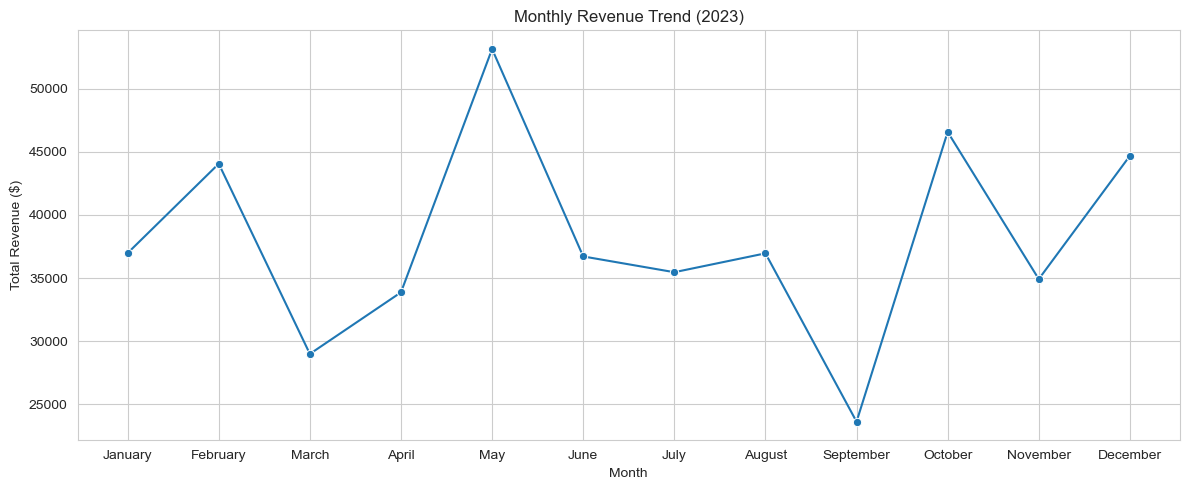

In [12]:
# Time-Based Sales Patterns
monthly = df.groupby(['Month', 'Month_Num']).agg(
    Revenue = ('Total Amount', 'sum'),
    Transactions = ('Transaction ID', 'count')
).reset_index().sort_values('Month_Num')

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly, x='Month', y='Revenue', marker='o', sort=False)
plt.title('Monthly Revenue Trend (2023)')
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
#plt.savefig('monthly_trend.png', dpi=100, bbox_inches='tight')
plt.show()

In [13]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Month_Num,Weekday,Age Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,November,11,Friday,26 - 35
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,February,2,Monday,26 - 35
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,January,1,Friday,46 - 55
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,May,5,Sunday,36 - 45
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,May,5,Saturday,26 - 35


In [14]:
# Popular Product Category

category_summary = df.groupby('Product Category').agg(
    Total_Revenue=('Total Amount', 'sum'),
    Transactions=('Transaction ID', 'count'),
    Avg_Order_Value=('Total Amount', 'mean'),
    Total_Units_Sold=('Quantity', 'sum')
).round(2).sort_values('Total_Revenue', ascending=False)

print(category_summary)

                  Total_Revenue  Transactions  Avg_Order_Value  \
Product Category                                                 
Electronics              156905           342           458.79   
Clothing                 155580           351           443.25   
Beauty                   143515           307           467.48   

                  Total_Units_Sold  
Product Category                    
Electronics                    849  
Clothing                       894  
Beauty                         771  


C:\Users\rmhar\AppData\Local\Temp\ipykernel_25376\2729507031.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_summary.reset_index(), x='Product Category', y='Total_Revenue', ax=axes[0], palette='mako')


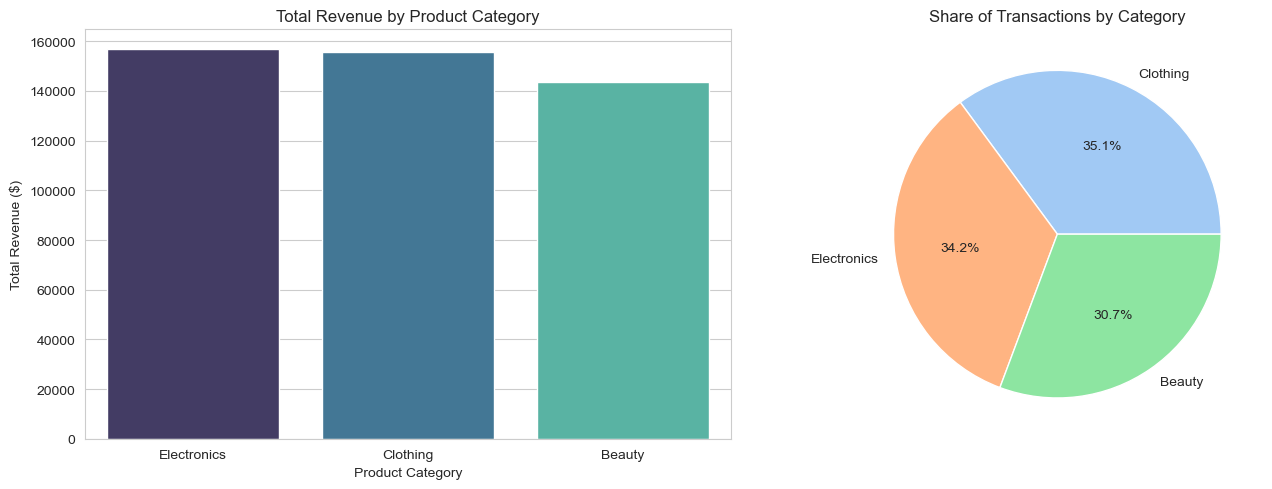

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.barplot(data=category_summary.reset_index(), x='Product Category', y='Total_Revenue', ax=axes[0], palette='mako')
axes[0].set_title('Total Revenue by Product Category')
axes[0].set_ylabel('Total Revenue ($)')

df['Product Category'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1], colors=sns.color_palette('pastel'))
axes[1].set_title('Share of Transactions by Category')
axes[1].set_ylabel('')

plt.tight_layout()
#plt.savefig('category_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

In [16]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Month_Num,Weekday,Age Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,November,11,Friday,26 - 35
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,February,2,Monday,26 - 35
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,January,1,Friday,46 - 55
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,May,5,Sunday,36 - 45
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,May,5,Saturday,26 - 35


Product Category  Beauty  Clothing  Electronics
Age Group                                      
18 - 25               51        44           53
26 - 35               67        74           64
36 - 45               54        76           72
46 - 55               71        76           82
56 - 65               55        74           66


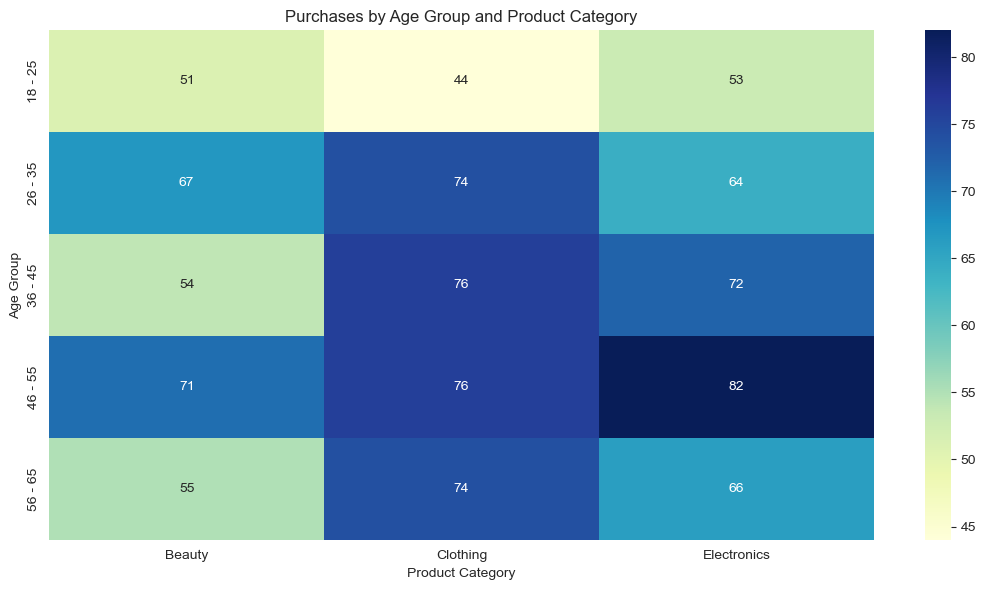

In [17]:
# relationships between age, spending, and product preferences
age_cat = pd.crosstab(df['Age Group'], df['Product Category'])
print(age_cat)

plt.figure(figsize=(11,6))
sns.heatmap(age_cat, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Purchases by Age Group and Product Category')
plt.tight_layout()
#plt.savefig('age_category_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

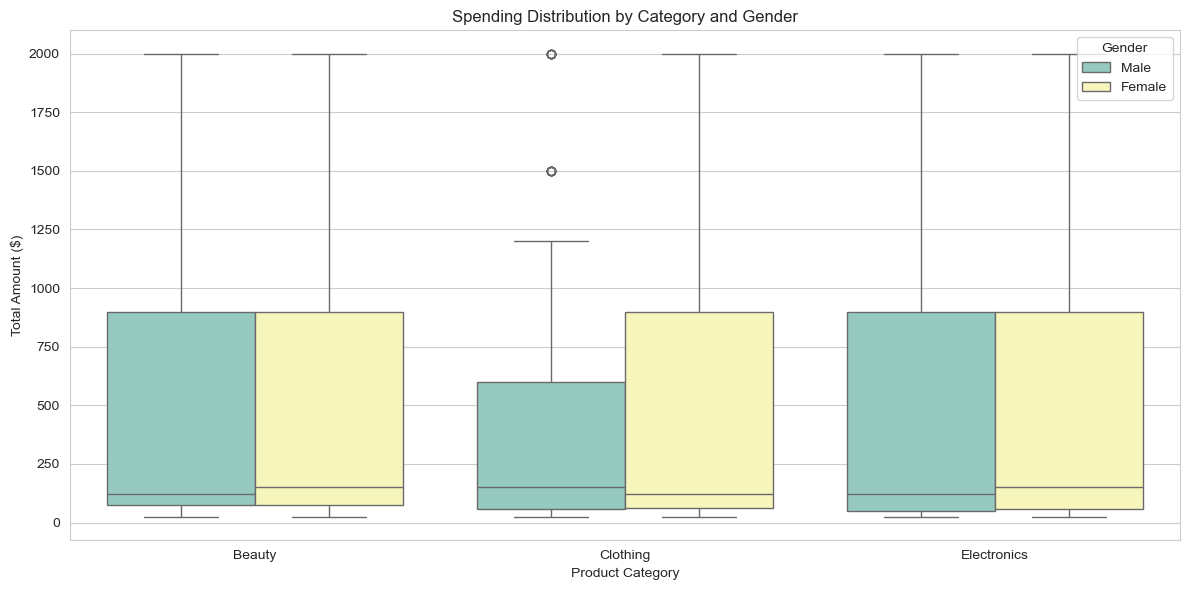

In [18]:
# Average spend by age group & category together
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='Product Category', y='Total Amount', hue='Gender', palette='Set3')
plt.title('Spending Distribution by Category and Gender')
plt.ylabel('Total Amount ($)')
plt.tight_layout()
#plt.savefig('category_gender_box.png', dpi=100, bbox_inches='tight')
plt.show()

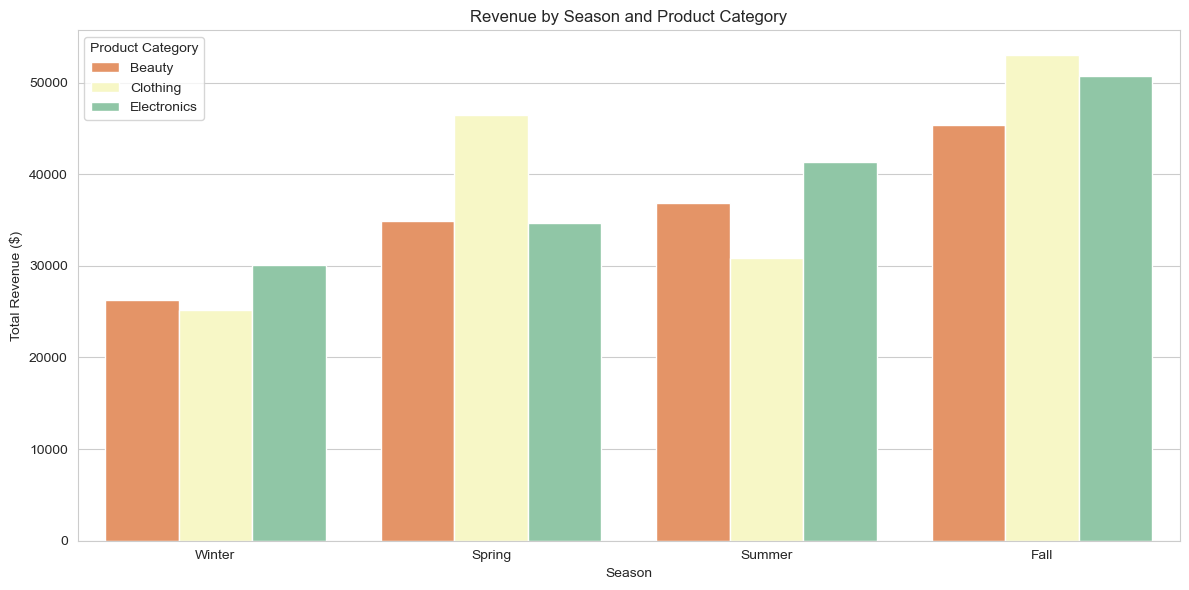

In [22]:
# seasonal trends

season_cat = df.groupby(['Season', 'Product Category']).agg(
    Revenue = ('Total Amount', 'sum')).reset_index()
season_order = ['Winter','Spring','Summer','Fall']

plt.figure(figsize=(12,6))
sns.barplot(data=season_cat, x='Season', y='Revenue', hue='Product Category', order=season_order, palette='Spectral')
plt.title('Revenue by Season and Product Category')
plt.ylabel('Total Revenue ($)')
plt.tight_layout()
#plt.savefig('seasonal_category.png', dpi=100, bbox_inches='tight')
plt.show()



          Avg_Total  Transactions
Quantity                         
1            177.09           253
2            333.54           243
3            598.69           241
4            706.69           263


C:\Users\rmhar\AppData\Local\Temp\ipykernel_25376\2422878406.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Quantity', ax=axes[0], palette='crest')
C:\Users\rmhar\AppData\Local\Temp\ipykernel_25376\2422878406.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Quantity', y='Total Amount', estimator=np.mean, errorbar=None, ax=axes[1], palette='crest')


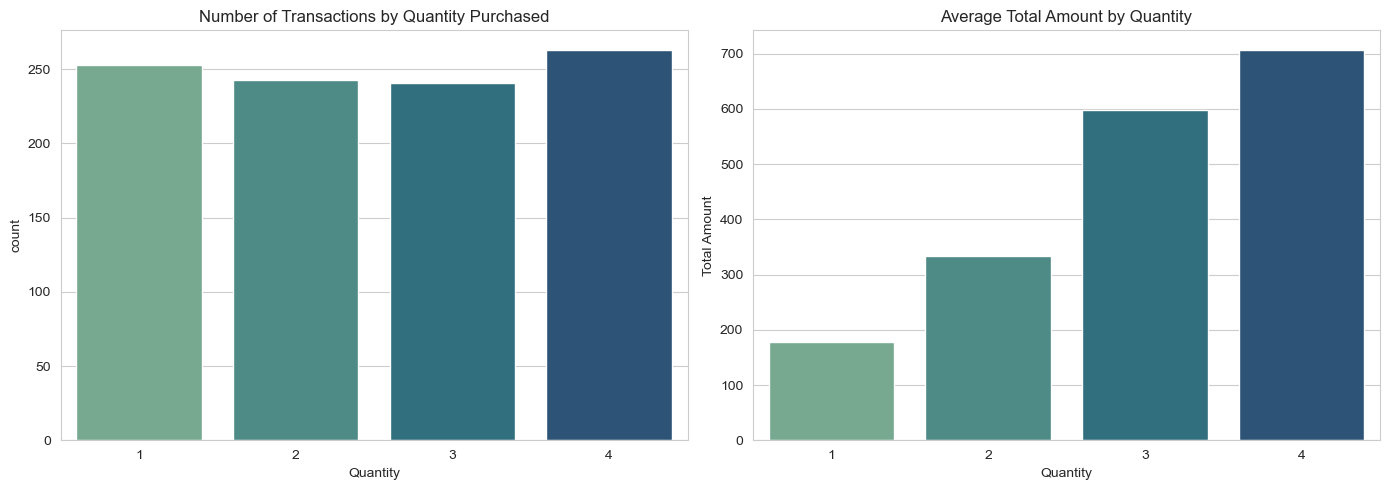

In [23]:
#  purchasing behaviors based on the number of items bought per transaction
qty_summary = df.groupby('Quantity').agg(
    Avg_Total = ('Total Amount', 'mean'),
    Transactions=('Transaction ID', 'count')
).round(2)
print(qty_summary)

fig, axes = plt.subplots(1,2, figsize=(14,5))
sns.countplot(data=df, x='Quantity', ax=axes[0], palette='crest')
axes[0].set_title('Number of Transactions by Quantity Purchased')

sns.barplot(data=df, x='Quantity', y='Total Amount', estimator=np.mean, errorbar=None, ax=axes[1], palette='crest')
axes[1].set_title('Average Total Amount by Quantity')

plt.tight_layout()
#plt.savefig('quantity_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

C:\Users\rmhar\AppData\Local\Temp\ipykernel_25376\154225638.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Product Category', y='Price per Unit', palette='muted')


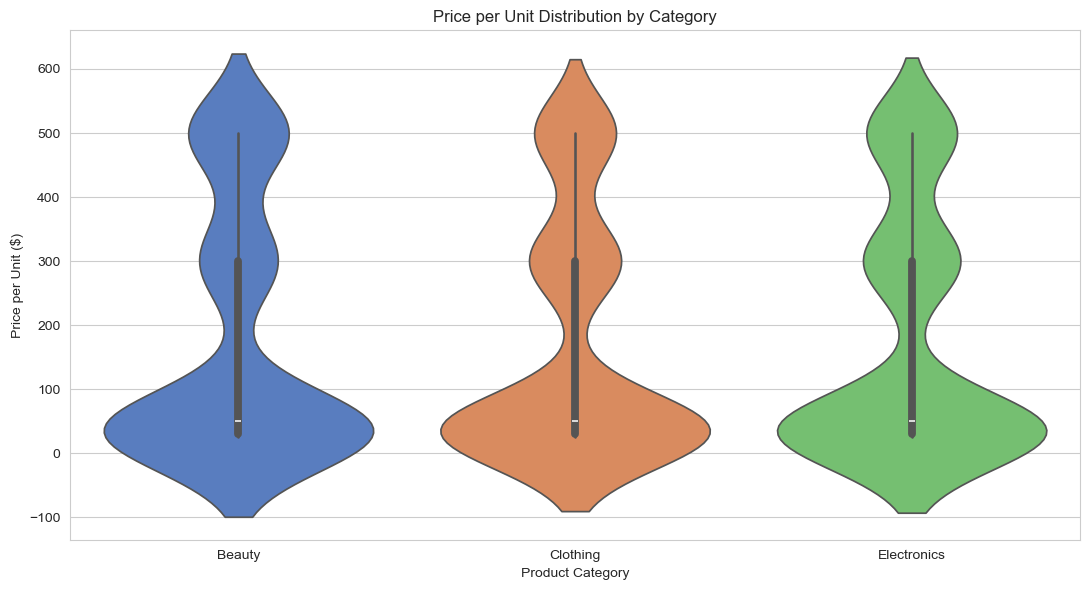

In [24]:
# distribution of product prices within each category
plt.figure(figsize=(11,6))
sns.violinplot(data=df, x='Product Category', y='Price per Unit', palette='muted')
plt.title('Price per Unit Distribution by Category')
plt.ylabel('Price per Unit ($)')
plt.tight_layout()
#plt.savefig('price_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

In [25]:
# Numeric summary of price per unit, by category
price_stats = df.groupby('Product Category')['Price per Unit'].describe().round(2)
print(price_stats)

                  count    mean     std   min   25%   50%    75%    max
Product Category                                                       
Beauty            307.0  184.06  194.93  25.0  30.0  50.0  300.0  500.0
Clothing          351.0  174.29  186.02  25.0  30.0  50.0  300.0  500.0
Electronics       342.0  181.90  189.05  25.0  30.0  50.0  300.0  500.0
